---

# Mapa de Mann-Kendall para Focos de Calor 2003-2024

---

- `OBJETIVO`:
> Este código calcula o teste de Mann-Kendall, extraindo o Slope e o P-valor e plota num mapa para o Estado de São Paulo. São utilizados dados de focos de calor anuais de 2003 à 2024 interpolados para uma grade de 20km.



- `DADOS DE ENTRADA`:
> Arquivo netcdf de focos de calor interpolados para uma grade de 20km para o Brasil. Acesso ao [arquivo](https://github.com/evmpython/000_CODIGOS_REFERENCIA/blob/main/07_TESTE_MANN_KENDALL/input/focos_anuais_brasil_20km_AQUA_2003_2025.nc). O arquivo nectdf foi criado utilizando os focos de calor disponibilizados pelo [INPE](https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_sat_ref/) do Satélite de referência AQUA de 2003 à 2024.


- `DADOS DE SAÍDA`:
> 1. Arquivo NETCDF contendo a `Inclinação (Slope) do Teste de Mann-Kendall` e `Valor-P (P-value) do Teste de Mann-Kendall` para cada pronto de grade da matriz de 20 km para o Estado de São Paulo. Acesso ao [arquivo](https://github.com/evmpython/000_CODIGOS_REFERENCIA/blob/main/07_TESTE_MANN_KENDALL/output/mann_kendall_results_focos_sp.nc). Exemplo: `mann_kendall_results_focos_sp.nc`.
> 2. Mapa em formato JPG dos valores do Slope e P-valor. Acesso a [figura](https://github.com/evmpython/000_CODIGOS_REFERENCIA/blob/main/07_TESTE_MANN_KENDALL/output/mann_kendall_focos_com_pvalue.jpg). Exemplo: `mann_kendall_focos_com_pvalue.jpg`


- `OBSERVAÇÕES`:
   > Nenhuma.

- `REALIZADO POR`:
> Prof. Enrique V. Mattos / UNIFEI - 29/05/2026

- `ATUALIZADO POR`:
> Prof. Enrique V. Mattos / UNIFEI - 29/05/2026
---


<>:250: SyntaxWarning: invalid escape sequence '\m'
<>:259: SyntaxWarning: invalid escape sequence '\m'
<>:250: SyntaxWarning: invalid escape sequence '\m'
<>:259: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_6189/3083117570.py:250: SyntaxWarning: invalid escape sequence '\m'
  label="$\mathbf{Sen's\;Slope\;(Fires/Year\;Trend)}$",
/tmp/ipykernel_6189/3083117570.py:259: SyntaxWarning: invalid escape sequence '\m'
  cbar.ax.set_ylabel("$\mathbf{Sen's\;Slope\;(Fires/Year\;Trend)}$", rotation=90, labelpad=20)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.1 MB/s eta 0:00:00
Mounted at /content/drive


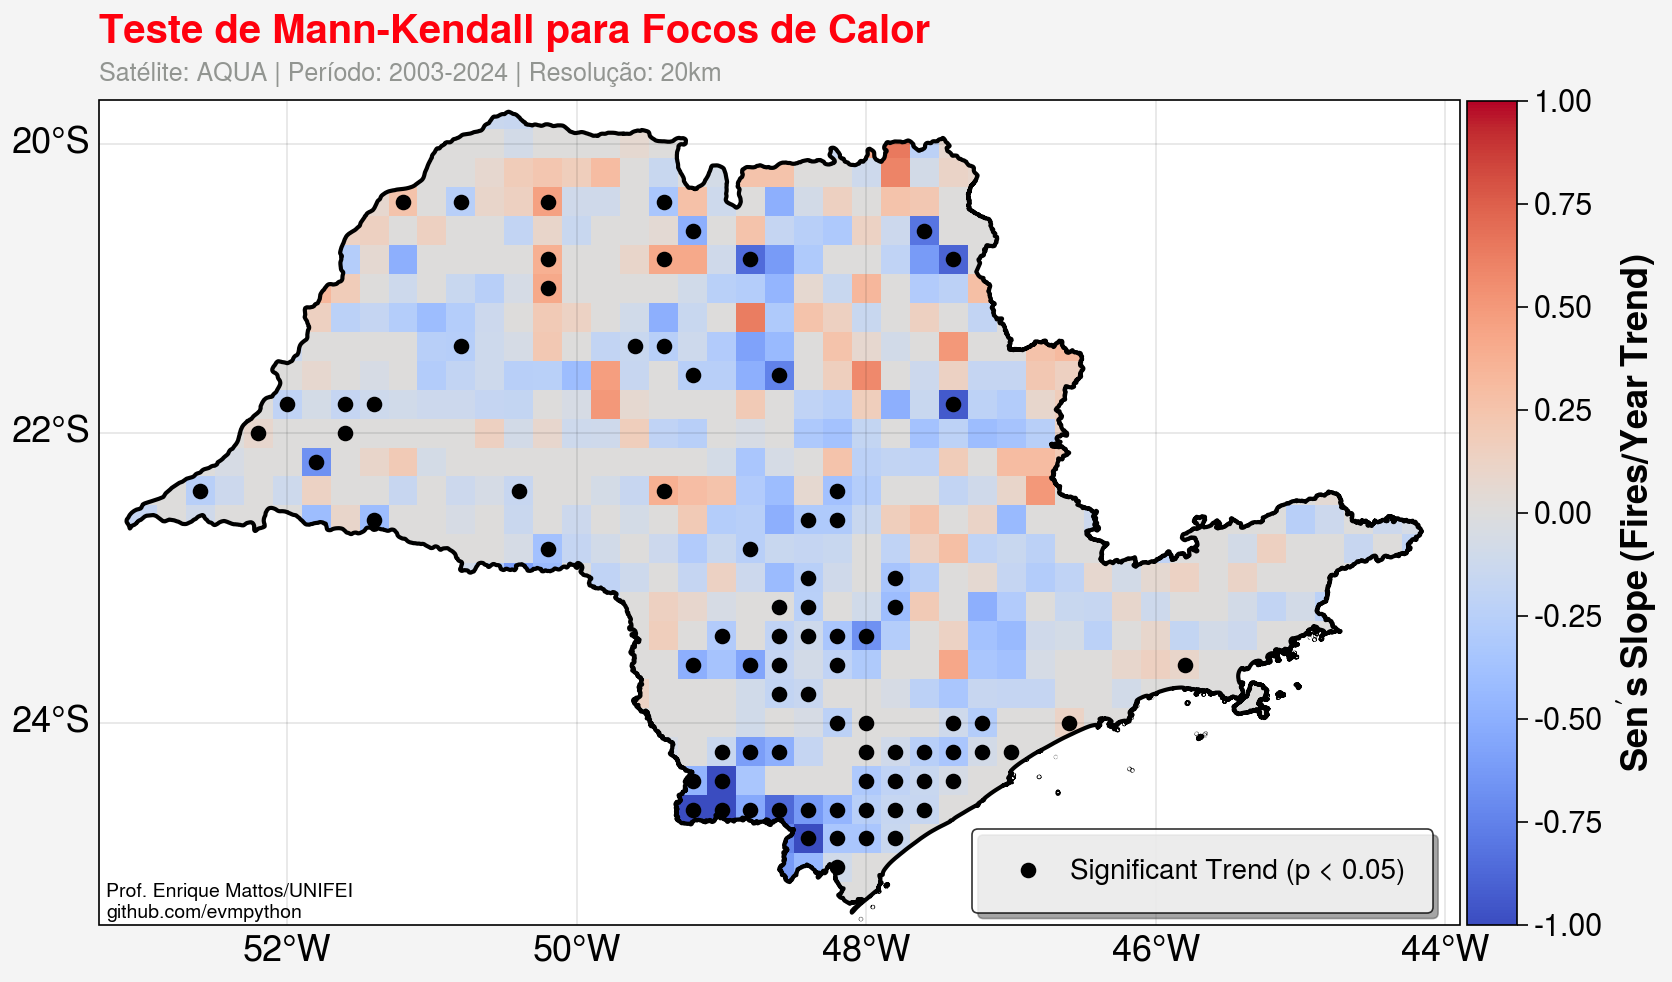

In [1]:
#=========================================================================================================================#
#                                          INSTALAÇÃO E IMPORTAÇÃO DAS BIBLIOTECAS
#=========================================================================================================================#
# instalação
!pip install -q ultraplot cartopy salem rasterio pyproj geopandas pymannkendall

# importação
import ultraplot as uplt
import numpy as np
import xarray as xr
import os
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
from matplotlib.ticker import FormatStrFormatter
import xarray as xr
import salem
import pymannkendall as mk

from cartopy.mpl.patch import geos_to_path
from matplotlib.path import Path
from matplotlib.patches import PathPatch

import warnings
warnings.filterwarnings("ignore")

#=========================================================================================================================#
#                                        MONTA O GOOGLE DRIVE E CRIA OS DIRETÓRIOS
#=========================================================================================================================#
# monta o drive
from google.colab import drive
drive.mount('/content/drive')

# diretório raiz
dir = '/content/drive/MyDrive/PYHTON/00_GITHUB/000_CODIGOS_REFERENCIA/07_TESTE_MANN_KENDALL'

# diretório de entrada
dir_input = f'{dir}/output/02_netcdf_focos_por_ano'

# diretório de saída
dir_output = f'{dir}/output/03_figuras'

# cria pasta de saída
os.makedirs(dir_output, exist_ok=True)

#=========================================================================================================================#
#                                              CARREGA SHAPEFILE DO ESTADO DE SP
#=========================================================================================================================#
# leitura do shapefile de SP
shapefile_sp = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp')

# é importante porque o NetCDF usa lon/lat e o Cartopy também vai plotar em PlateCarree
shapefile_sp = shapefile_sp.to_crs("EPSG:4326") # Pois os dois tem que se conversar

# limites do estado de SP
lonmin_sp, lonmax_sp, latmin_sp, latmax_sp = -53.3, -43.9, -25.4, -19.7

#=========================================================================================================================#
#                                      LEITURA DO ARQUIVO NETCDF DE FOCOS DE CALOR
#=========================================================================================================================#
# leitura do arquivo netcdf de focos de calor com 20km de resolução espacial
focos_por_ano_2003_a_2024 = xr.open_dataset(f'{dir_input}/focos_anuais_brasil_20km_AQUA_2003_2025.nc')

# recorta os dados para o Estado de SP de 2003 à 2024
focos_por_ano_2003_a_2024_sp = focos_por_ano_2003_a_2024.sel(lat=slice(latmax_sp, latmin_sp), lon=slice(lonmin_sp, lonmax_sp)).sel(time=slice('2003', '2024'))

#=========================================================================================================================#
#                                               CALCULA TESTE DE MANN-KENDALL
#=========================================================================================================================#
#------------------------------------------------------------------#
#           Função que calcula o teste de Mann-kendall
#------------------------------------------------------------------#
def mann_kendall(time_series_data):

    # garante que os dados não são todos "NaN" e que há pelo menos 3 pontos não-NaN
    data_non_nan = time_series_data[~np.isnan(time_series_data)]
    if data_non_nan.size < 3:
        return np.nan, np.nan

    # executa o teste original de Mann-Kendall
    result = mk.original_test(data_non_nan)

    # retorna o slope (inclinação) e o p-value (valor-p) do teste de Mann-Kendall
    return result.slope, result.p

#------------------------------------------------------------------#
#               Aplica a função por ponto de grade
#------------------------------------------------------------------#
# aplica a função universal (Ufunc) ao DataArray 'focos'. Isso permite aplicar a função 'mann_kendall' a cada série temporal (cada ponto de grade) de forma eficiente
slope_p_values = xr.apply_ufunc(mann_kendall,
                                focos_por_ano_2003_a_2024_sp['focos'],
                                input_core_dims = [['time']],            # indica que a função opera ao longo da dimensão 'time' de cada série
                                output_core_dims = [[], []],             # a saída são dois valores escalares (slope e p-value) para cada ponto de grade
                                exclude_dims = set(('time',)),           # a dimensão 'time' é consumida pela função interna
                                vectorize = True,                        # importante para aplicar uma função de 1D em "fatias" de arrays multidimensionais
                                dask = 'parallelized',                   # habilita o Dask para computação paralela, se o xarray estiver configurado para isso
                                output_dtypes = [np.float64, np.float64] # define explicitamente os tipos de dados de saída
                                )

#------------------------------------------------------------------#
#                    Salva arquivo NetCDF
#------------------------------------------------------------------#
# desempacota os resultados em DataArrays separados para as variáveis 'slope' e 'p_value'
slope = slope_p_values[0]
p_value = slope_p_values[1]

# atribui nomes aos DataArrays resultantes
slope.name = 'slope'
p_value.name = 'p_value'

# adiciona atributos 'long_name' e 'units' para descrição no NetCDF
slope.attrs['long_name'] = 'Inclinação (Slope) do Teste de Mann-Kendall'
slope.attrs['units'] = 'focos por ano'
p_value.attrs['long_name'] = 'Valor-P (P-value) do Teste de Mann-Kendall'
p_value.attrs['units'] = 'adimensional'

# cria um novo Dataset com os resultados do Mann-Kendall
mann_kendall_results_ds = xr.Dataset({'slope': slope, 'p_value': p_value})

# define o caminho completo para o arquivo NetCDF de saída
output_filename = os.path.join(dir_output, 'mann_kendall_results_focos_sp.nc')

# salva os resultados em um arquivo NetCDF
mann_kendall_results_ds.to_netcdf(output_filename)

#=========================================================================================================================#
#                                                      PLOTA FIGURA
#=========================================================================================================================#
#------------------------------------------------------------------#
#                     Formatação da figura
#------------------------------------------------------------------#
# cria a moldura da figura
fig, ax = uplt.subplots(axheight=4.5, axwidth=6.8, tight=True, proj='pcarree')

# formatação dos eixos
ax.format(coast=False, borders=False, innerborders=False,
          labels=True, latlines=2, lonlines=2,
          latlim=(latmin_sp+0., latmax_sp-0.), lonlim=(lonmin_sp+0., lonmax_sp-0.),
          small='18px', large='20px',
          title=f'Teste de Mann-Kendall para Focos de Calor \n',
          titleloc='l',
          titleweight='bold',
          titlecolor='bright red')

# plota subtítulo
ax.text(0.000, 1.046,
        f'Satélite: AQUA | Período: 2003-2024 | Resolução: 20km',
        transform=ax.transAxes,
        color='gray',
        fontsize=9,
        verticalalignment='top')

#------------------------------------------------------------------#
#      Recorta dado de Mann-Kendall para o Estado de SP
#------------------------------------------------------------------#
slope_data_roi = mann_kendall_results_ds['slope'][:,:] #.salem.roi(shape=shapefile_sp)

#------------------------------------------------------------------#
#              Define os limites da imagem
#------------------------------------------------------------------#
# extrai as latitudes e longitudes do dataset
lon_coords = mann_kendall_results_ds['lon'].values
lat_coords = mann_kendall_results_ds['lat'].values

# calcula o espaçamento de grade em 'X' e 'Y'
if len(lon_coords) > 1:
    dx = np.abs(lon_coords[1] - lon_coords[0])
else:
    dx = 0.2 # padrão se apenas 1 ponto de longitude

if len(lat_coords) > 1:
    dy = np.abs(lat_coords[1] - lat_coords[0])
else:
    dy = 0.2 # padrão se apenas 1 ponto de latitude

# encontra a longitude mínima e máxima
lon_min_extent = lon_coords[0] - dx / 2
lon_max_extent = lon_coords[-1] + dx / 2

# encontra a latitude mínima e máxima
lat_min_extent = lat_coords[-1] - dy / 2
lat_max_extent = lat_coords[0] + dy / 2

# coloca numa lista os limites da imagem
extent = [lon_min_extent, lon_max_extent, lat_min_extent, lat_max_extent]

#------------------------------------------------------------------#
#             Plota mapa dos valores do Slope
#------------------------------------------------------------------#
# plota mapa
map1 = ax.imshow(slope_data_roi.values,
                 cmap='coolwarm',
                 extent=extent,
                 transform=ccrs.PlateCarree(),
                 origin='upper',
                 vmin=-1.0, vmax=1.0)

#------------------------------------------------------------------#
#             Mapa com suavização nas bordas
#------------------------------------------------------------------#
# mesmo que o shapefile tenha mais de uma feição, essa linha junta tudo em uma única geometria
geom_sp = shapefile_sp.geometry.unary_union # isso garante que não vai ter um bug que não reconhece um "polygon"

# pega os limites do shapefile
minx, miny, maxx, maxy = shapefile_sp.total_bounds # aqui é para não bugar com os pixels, usado para recortar usando o shape de são paulo e não usando o pixel

# converte a geometria do shapefile de SP em um caminho do Matplotlib
paths = geos_to_path([geom_sp])

# junta todos os caminhos em um único, pois assim fica tudo em unico recorte
clip_path = Path.make_compound_path(*paths)

# aqui unifica todos em um unico shape e corte
clip_patch = PathPatch(clip_path, transform=ax.transData, facecolor="none")

# aplica o recorte visual no próprio GeoQuadMesh retornado pelo xarray.plot()
# essa linha faz o dado aparecer somente dentro do limite de SP
map1.set_clip_path(clip_patch)
#------------------------------------------------------------------#

# adiciona o shapefile do Estado de SP
shapefile = list(shpreader.Reader('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.5)

#------------------------------------------------------------------#
#            Plota o P-value (< 0.05) como pontos
#------------------------------------------------------------------#
# calcula as coordenadas dos pixels com 'p_value < 0.05' dentro da área do Estado de SP
p_value_data_sp = mann_kendall_results_ds['p_value'].salem.roi(shape=shapefile_sp)
significant_mask = (p_value_data_sp < 0.05) & (~np.isnan(p_value_data_sp))

# cria uma grade de longitudes e latitudes
lon_grid, lat_grid = np.meshgrid(mann_kendall_results_ds['lon'].values, mann_kendall_results_ds['lat'].values)

# filtra as coordenadas para onde o p_value é significativo (ou seja, onde 'p < 0.05')
sig_lon_coords = lon_grid[significant_mask.values]
sig_lat_coords = lat_grid[significant_mask.values]

# plota os pontos significativos como bolinhas pretas e adiciona label para a legenda
ax.scatter(sig_lon_coords, sig_lat_coords, s=25, color='black', marker='o', transform=ccrs.PlateCarree(), zorder=2, label='Significant Trend (p < 0.05)')

#------------------------------------------------------------------#
#                 Plota barra de cores
#------------------------------------------------------------------#
# plota barra de cores da figura
cbar = fig.colorbar(map1,
                    loc='r',
                    label="$\mathbf{Sen's\;Slope\;(Fires/Year\;Trend)}$",
                    ticks=mticker.MultipleLocator(0.25),
                    ticklabelsize=11,
                    labelsize=13,
                    length=0.915,
                    width=0.25,
                    space=0.3)

# adiciona rotação ao nome da barra de cores
cbar.ax.set_ylabel("$\mathbf{Sen's\;Slope\;(Fires/Year\;Trend)}$", rotation=90, labelpad=20)

# labels com 2 casas decimais
cbar.formatter = FormatStrFormatter("%.2f")
cbar.update_ticks()
cbar.ax.minorticks_off()

#------------------------------------------------------------------#
#                  Adiciona legenda da figura
#------------------------------------------------------------------#
# adiciona a legenda
ax.legend(loc='lower right', bbox_to_anchor=(0.98, 0.015), frameon=True, fancybox=True, shadow=True, borderpad=1, fontsize=10)

# informação na figura
ax.annotate('Prof. Enrique Mattos/UNIFEI\ngithub.com/evmpython', xy=(lonmin_sp+0.05,latmin_sp+0.05), fontsize=7, color='black')

#------------------------------------------------------------------#
#                       Salva figura
#------------------------------------------------------------------#
# salva figura
fig.savefig(f'{dir_output}/mann_kendall_focos_com_pvalue.jpg', dpi=300, bbox_inches="tight")

In [2]:
# mostra os dados de focos abrangendo o Brasil
focos_por_ano_2003_a_2024

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 23, lat: 210, lon: 210)
Coordinates:
  * time     (time) datetime64[ns] 184B 2003-01-01 2004-01-01 ... 2025-01-01
  * lat      (lat) float64 2kB 7.0 6.8 6.6 6.4 6.2 ... -34.2 -34.4 -34.6 -34.8
  * lon      (lon) float64 2kB -75.0 -74.8 -74.6 -74.4 ... -33.6 -33.4 -33.2
Data variables:
    focos    (time, lat, lon) int32 4MB ...

In [3]:
# mostra os dados de focos abrangendo o Estado de SP
focos_por_ano_2003_a_2024_sp

<xarray.Dataset> Size: 117kB
Dimensions:  (time: 22, lat: 28, lon: 47)
Coordinates:
  * time     (time) datetime64[ns] 176B 2003-01-01 2004-01-01 ... 2024-01-01
  * lat      (lat) float64 224B -19.8 -20.0 -20.2 -20.4 ... -24.8 -25.0 -25.2
  * lon      (lon) float64 376B -53.2 -53.0 -52.8 -52.6 ... -44.4 -44.2 -44.0
Data variables:
    focos    (time, lat, lon) int32 116kB 7 0 6 1 17 3 5 2 ... 0 0 0 0 0 0 0 0

In [4]:
# dados de Mann_kendall
mann_kendall_results_ds

<xarray.Dataset> Size: 22kB
Dimensions:  (lat: 28, lon: 47)
Coordinates:
  * lat      (lat) float64 224B -19.8 -20.0 -20.2 -20.4 ... -24.8 -25.0 -25.2
  * lon      (lon) float64 376B -53.2 -53.0 -52.8 -52.6 ... -44.4 -44.2 -44.0
Data variables:
    slope    (lat, lon) float64 11kB -0.125 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    p_value  (lat, lon) float64 11kB 0.005123 1.0 0.2258 0.6049 ... 1.0 1.0 1.0